# XGBoost check: does cognition add *nonlinear* predictive value for symptoms?

The CCA ladder found only ~1% shared variance and no nonlinear/foundation-model arm beat the linear baseline; the Anna Karenina deviation test was similarly null. Those framings look for a *shared axis* or a *deviation-magnitude* signal. This is a direct predictive check for any nonlinearity they might miss.

For each survey score we compare two gradient-boosted tree models on held-out data:

* **null** — features = `age`, `sex`
* **full** — features = `age`, `sex` + the 30 cognitive task parameters

A tree recovers `age²` and `age×sex` from `age` and `sex` by splitting, so the arms differ **only** in whether the cognitive parameters are available. XGBoost captures arbitrary nonlinear interactions among the 30 parameters that CCA/rCCA cannot, so a null result here is strong evidence there is no recoverable nonlinear cognition→symptom relationship.

Inference uses the **SHARP** estimator (Zeng et al. 2026) on the paired per-half difference in held-out R² (full − null): a valid analytic, fold-dependence-aware p-value, one-sided (full > null). Both arms use the identical algorithm (fixed shallow trees; number of rounds tuned by early stopping inside each training fold).

**Training half only** (N=1298 after the `max_rhat>1.1` exclusion, matching the CCA run); the held-out half is never read.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
res = pl.read_parquet("../data/exploratory/xgb_nonlinear_results.parquet")
print(f"targets: {res.height} | N: {res['n'][0]} | J={res['J'][0]}, K={res['K'][0]}")

targets: 20 | N: 1298 | J=30, K=5


## 1. Per-target held-out R² gain (full − null), SHARP inference

`mean_r2_gain` is the SHARP D̄ (mean over halves/reps); `p_one_sided` tests full > null; `q_fdr` is BH-FDR across the 20 survey scores.

In [2]:
tbl = (res.select(['target', 'mean_r2_gain', 'ci_lo', 'ci_hi',
                   'p_one_sided', 'q_fdr', 'rho'])
          .with_columns([pl.col(c).round(4) for c in
                         ['mean_r2_gain', 'ci_lo', 'ci_hi', 'p_one_sided', 'q_fdr', 'rho']]))
print(tbl)
n_sig = int((res['q_fdr'] < 0.05).sum())
print(f"\nTargets surviving BH-FDR (q<0.05): {n_sig} / {res.height}")

shape: (20, 7)
┌───────────────────┬──────────────┬─────────┬─────────┬─────────────┬───────┬────────┐
│ target            ┆ mean_r2_gain ┆ ci_lo   ┆ ci_hi   ┆ p_one_sided ┆ q_fdr ┆ rho    │
│ ---               ┆ ---          ┆ ---     ┆ ---     ┆ ---         ┆ ---   ┆ ---    │
│ str               ┆ f64          ┆ f64     ┆ f64     ┆ f64         ┆ f64   ┆ f64    │
╞═══════════════════╪══════════════╪═════════╪═════════╪═════════════╪═══════╪════════╡
│ hitop_hypsom      ┆ -0.0005      ┆ -0.0195 ┆ 0.0185  ┆ 0.5213      ┆ 1.0   ┆ 0.242  │
│ hitop_welbe       ┆ -0.0013      ┆ -0.0178 ┆ 0.0151  ┆ 0.5622      ┆ 1.0   ┆ 0.2626 │
│ hitop             ┆ -0.0177      ┆ -0.0439 ┆ 0.0085  ┆ 0.9075      ┆ 1.0   ┆ 0.2703 │
│ hitop_socanx      ┆ -0.0159      ┆ -0.0376 ┆ 0.0058  ┆ 0.9245      ┆ 1.0   ┆ 0.2668 │
│ gad7              ┆ -0.0122      ┆ -0.0273 ┆ 0.0028  ┆ 0.9446      ┆ 1.0   ┆ 0.1705 │
│ …                 ┆ …            ┆ …       ┆ …       ┆ …           ┆ …     ┆ …      │
│ hitop_insom    

## 2. Held-out R² gain per survey score with SHARP 95% CI

Points right of 0 mean the cognitive parameters improved held-out prediction. Red = survives BH-FDR (q<0.05).

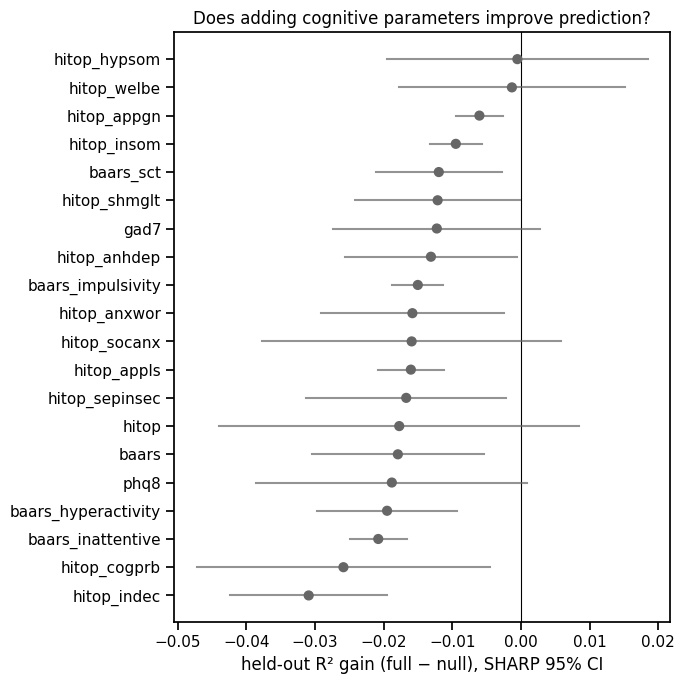

In [3]:
d = res.sort('mean_r2_gain')
targets = d['target'].to_list()
gain = d['mean_r2_gain'].to_numpy()
lo, hi = d['ci_lo'].to_numpy(), d['ci_hi'].to_numpy()
q = d['q_fdr'].to_numpy()
y = np.arange(len(targets))
colors = np.where(q < 0.05, 'crimson', '0.4')

fig, ax = plt.subplots(figsize=(7, 7))
ax.axvline(0, color='k', lw=0.8, zorder=0)
for i in range(len(targets)):
    ax.plot([lo[i], hi[i]], [y[i], y[i]], color=colors[i], lw=1.5, alpha=0.7)
ax.scatter(gain, y, c=colors, s=40, zorder=5)
ax.set_yticks(y); ax.set_yticklabels(targets)
ax.set_xlabel('held-out R² gain (full − null), SHARP 95% CI')
ax.set_title('Does adding cognitive parameters improve prediction?')
plt.tight_layout()
plt.show()

## Conclusion

**Decisive null.** For every one of the 20 survey scores the held-out R² gain from adding the 30 cognitive parameters is **negative** — the full model predicts *worse* than the age+sex baseline, i.e. the parameters act as noise that a gradient-boosted tree cannot turn into signal. All one-sided SHARP p-values are ≥ 0.52 (most ≈ 1.0), and **no target survives BH-FDR** (all q = 1.0). The closest-to-zero targets (`hitop_hypsom`, `hitop_welbe`) are still negative and non-significant.

This is a strong, model-agnostic corroboration of the earlier results: the CCA ladder found no shared axis (~1% linear variance, no nonlinear/FM arm beating linear) and the Anna Karenina deviation test was null. XGBoost — which can capture arbitrary nonlinear interactions among the parameters — finds no nonlinear cognition→symptom relationship either. Within this training half, cognitive task parameters carry no recoverable predictive information about symptom scores beyond demographics.

_Training half only; the held-out half remains untouched for any future confirmatory step._